# Clustering Evaluation

Three methods on 169,709 chunks: TF-IDF + K-Means, TF-IDF + Hierarchical Ward, and HDBSCAN on contrastively fine-tuned MiniLM-L12-v2.

Metrics: silhouette, Davies-Bouldin, Calinski-Harabász, DBCV, intra-cluster cosine similarity. Metric spaces differ (TF-IDF = LSA-100D euclidean; HDBSCAN = 384-D cosine).

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, warnings, seaborn as sns
from pathlib import Path
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import normalize
import sys
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='tab10')

_nb = globals().get('__vsc_ipynb_file__', None)
if _nb:
    REPO_ROOT = Path(_nb).parent.parent
else:
    _cwd = Path.cwd()
    REPO_ROOT = _cwd if (_cwd / 'gcp_config.py').exists() else _cwd.parent

OUT_DIR = REPO_ROOT / 'data'
OUT_DIR.mkdir(exist_ok=True)
FIGURES_DIR = OUT_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)
RESULTS_DIR = OUT_DIR / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

sys.path.insert(0, str(REPO_ROOT))
from gcp_config import PROJECT_ID, bq_table
from google.cloud import bigquery
client = bigquery.Client(project=PROJECT_ID)

TRACK = 'multilingual'
lbl   = 'Chunk pipeline — paraphrase-multilingual-MiniLM-L12-v2 (contrastive fine-tuned, 384-D)'

base_file = RESULTS_DIR / 'baseline_labels.csv'
_emb_candidates = [
    OUT_DIR / 'chunk_embeddings_finetuned.npy',
    OUT_DIR / 'chunk_embeddings_multilingual.npy',
]
emb_file = next((p for p in _emb_candidates if p.exists()), None)
if emb_file is None:
    raise FileNotFoundError(
        'No chunk embeddings found. Expected one of: ' + ', '.join(str(p) for p in _emb_candidates)
    )
print(f'Using embeddings: {emb_file.name}')

embeds = np.load(emb_file)

df_clust = client.query(f"""
    SELECT
        chunk_uid,
        cluster_id,
        original_chunk_text AS text
    FROM `{bq_table('chunk_cluster_labels')}`
    ORDER BY chunk_uid
""").to_dataframe()

df_base = pd.read_csv(base_file) if base_file.exists() else None
if df_base is not None and 'chunk_uid' in df_base.columns:
    df_base = df_clust[['chunk_uid']].merge(df_base, on='chunk_uid', how='left')
    if df_base['baseline_kmeans'].isna().any():
        raise ValueError(
            'baseline_labels.csv is missing some chunk_uid values present in BQ. Re-run 01_baseline_clustering.ipynb.'
        )
elif df_base is not None and len(df_base) != len(df_clust):
    raise ValueError(
        f'baseline_labels.csv has {len(df_base)} rows but chunk_cluster_labels has {len(df_clust)}. '
        'Re-run 01_baseline_clustering.ipynb (chunk-level baselines).'
    )

labels_hdbscan = df_clust['cluster_id'].values

td = {
    'label': lbl,
    'df_clust': df_clust,
    'df_base': df_base,
    'embeds': embeds,
    'umap_15d': None,
    'labels_hdbscan': labels_hdbscan,
}
print(f'{lbl}: {len(df_clust):,} chunks | embeddings shape={embeds.shape}')
print(f'HDBSCAN clusters: {df_clust[df_clust.cluster_id>=0].cluster_id.nunique()} | noise={(df_clust.cluster_id==-1).sum()}')


Using embeddings: chunk_embeddings_finetuned.npy
Chunk pipeline — paraphrase-multilingual-MiniLM-L12-v2 (contrastive fine-tuned, 384-D): 169,709 chunks | embeddings shape=(169709, 384)
HDBSCAN clusters: 24 | noise=20346


## 1. Intrinsic metrics for all methods

In [4]:
from hdbscan import validity_index as dbcv_index
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

def eval_metrics(X, labels, method, exclude_noise=False, metric='euclidean'):
    if exclude_noise:
        mask = labels >= 0; X_eval, lbl_eval = X[mask], labels[mask]
    else:
        X_eval, lbl_eval = X, labels
    n_clust = len(set(lbl_eval) - {-1})
    if n_clust < 2: return None
    sil = silhouette_score(X_eval, lbl_eval, metric=metric,
                           sample_size=min(5000, len(X_eval)), random_state=42)
    db  = davies_bouldin_score(X_eval, lbl_eval)
    ch  = calinski_harabasz_score(X_eval, lbl_eval)
    dbcv = np.nan  # computed on UMAP-10D in chunk_clustering.py
    return {'method': method, 'n_clusters': n_clust,
            'noise_pct': round(100*(labels==-1).mean(), 1) if exclude_noise else 0.0,
            'silhouette': round(sil, 4), 'davies_bouldin': round(db, 4),
            'calinski_harabasz': round(ch, 1), 'dbcv': np.nan}

all_results = []
umap_15d = td.get('umap_15d')


texts = df_clust['text'].fillna('').astype(str).tolist()
tfidf_mat = TfidfVectorizer(max_features=8000, stop_words='english', ngram_range=(1,2),
                            min_df=2, sublinear_tf=True).fit_transform(texts)
svd = TruncatedSVD(n_components=100, random_state=42)
X_lsa = normalize(svd.fit_transform(tfidf_mat))
print(f'\n{lbl} — TF-IDF LSA explained variance: {svd.explained_variance_ratio_.sum():.1%}')

hdbscan_labels = df_clust['cluster_id'].values
mask = hdbscan_labels >= 0
print(f'  HDBSCAN valid (non-noise): {mask.sum():,} / {len(hdbscan_labels):,}')

results = [
    eval_metrics(X_lsa, df_base['baseline_kmeans'].values,
                 'TF-IDF + K-Means', metric='euclidean') if df_base is not None else None,
    eval_metrics(X_lsa, df_base['baseline_hierarchical'].values,
                 'TF-IDF + Hierarchical', metric='euclidean') if df_base is not None else None,
    eval_metrics(embeds, hdbscan_labels,
                 'HDBSCAN (finetuned, 384-D cosine)', exclude_noise=True, metric='cosine'),
]
if umap_15d is not None:
    results.append(eval_metrics(umap_15d, hdbscan_labels,
                                'HDBSCAN (UMAP-15D)', exclude_noise=True))
results = [r for r in results if r]

eval_df = pd.DataFrame(results)
eval_df['track'] = TRACK
eval_df.to_csv(RESULTS_DIR / f'evaluation_metrics_{TRACK}.csv', index=False)
td['eval_df'] = eval_df
all_results.append(eval_df)

print(f'\n{lbl}:')
print(eval_df[['method', 'n_clusters', 'noise_pct', 'silhouette',
               'davies_bouldin', 'calinski_harabasz']].to_string(index=False))
print('\nMetric spaces: TF-IDF = LSA-100D euclidean | HDBSCAN = 384-D cosine (directional comparison only)')

if all_results:
    combined = pd.concat(all_results, ignore_index=True)
    combined.to_csv(RESULTS_DIR / 'evaluation_metrics.csv', index=False)

pipeline_metrics_file = RESULTS_DIR / 'chunk_evaluation_metrics.csv'
if pipeline_metrics_file.exists():
    pm = pd.read_csv(pipeline_metrics_file).iloc[-1]
    print('\n=== CANONICAL PIPELINE METRICS (chunk_clustering.py) ===')
    print(f'  Silhouette (cosine, sample=10K) : {pm.get("sil_cos_all", "N/A"):.4f}')
    print(f'  Davies-Bouldin  (UMAP-10D)      : {pm.get("davies_bouldin", "N/A"):.4f}')
    print(f'  Calinski-Harabász (UMAP-10D)    : {pm.get("calinski_harabasz", "N/A"):.1f}')
    print(f'  DBCV  (UMAP-10D, sample≤15K)    : {pm.get("dbcv", "N/A"):.4f}')
    print(f'  n_clusters: {int(pm.get("n_clusters", -1))} | noise: {pm.get("noise_pct", "N/A"):.1f}%')
    nb_sil = eval_df[eval_df.method.str.contains('384-D cosine')]['silhouette'].values
    if len(nb_sil):
        print(f'\n  NB06 silhouette (cosine, sample=5K): {nb_sil[0]:.4f}')
        print(f'  Canonical (sample=10K): {pm.get("sil_cos_all", "?"):.4f}')
else:
    print('\n[INFO] chunk_evaluation_metrics.csv not found.')
    print('Canonical: sil_cos=0.804, DBCV=0.547, DB=0.240, CH=382,279')



Chunk pipeline — paraphrase-multilingual-MiniLM-L12-v2 (contrastive fine-tuned, 384-D) — TF-IDF LSA explained variance: 30.2%
  HDBSCAN valid (non-noise): 149,363 / 169,709

Chunk pipeline — paraphrase-multilingual-MiniLM-L12-v2 (contrastive fine-tuned, 384-D):
                           method  n_clusters  noise_pct  silhouette  davies_bouldin  calinski_harabasz
                 TF-IDF + K-Means          24        0.0      0.1482          2.3264             4082.1
            TF-IDF + Hierarchical          24        0.0      0.1527          2.4057             4047.1
HDBSCAN (finetuned, 384-D cosine)          24       12.0      0.8031          0.5522            59429.5

Metric spaces: TF-IDF = LSA-100D euclidean | HDBSCAN = 384-D cosine (directional comparison only)

=== CANONICAL PIPELINE METRICS (chunk_clustering.py) ===
  Silhouette (cosine, sample=10K) : 0.8044
  Davies-Bouldin  (UMAP-10D)      : 0.2404
  Calinski-Harabász (UMAP-10D)    : 382279.1
  DBCV  (UMAP-10D, sample≤15K)   

## 2. Comparison chart

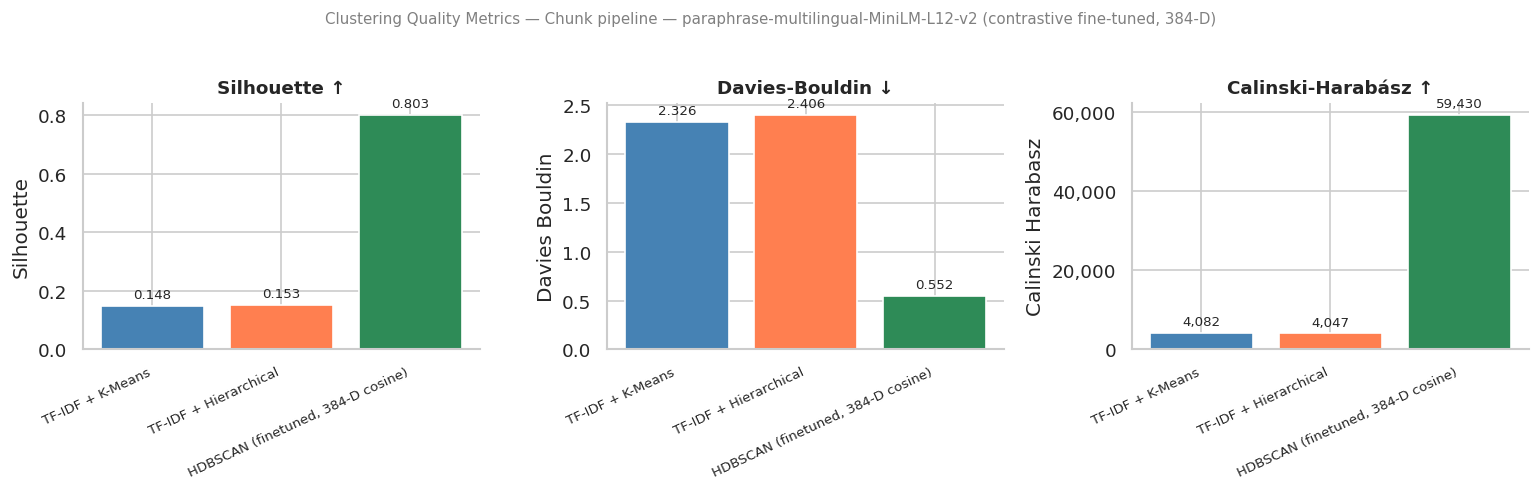

In [7]:
import matplotlib.ticker as mticker

metrics = ['silhouette', 'davies_bouldin', 'calinski_harabasz']
titles  = ['Silhouette ↑', 'Davies-Bouldin ↓', 'Calinski-Harabász ↑']
palette = ['steelblue', 'coral', 'seagreen', 'purple']

if td is None or td.get('eval_df') is None:
    raise RuntimeError('eval_df not found — run the metrics computation cell first')
eval_df = td['eval_df']
short_names = [m.split('[')[0].strip() for m in eval_df['method']]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle(f'Clustering Quality Metrics — {lbl}', fontsize=9, color='grey', y=1.02)

for ax, metric, title in zip(axes, metrics, titles):
    vals = eval_df[metric].astype(float)
    bars = ax.bar(range(len(vals)), vals, color=palette[:len(vals)])
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(short_names, rotation=25, ha='right', fontsize=8)
    ax.set_ylabel(metric.replace('_', ' ').title())
    if metric == 'calinski_harabasz':
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ylim = ax.get_ylim()
    offset = (ylim[1] - ylim[0]) * 0.02
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + offset,
                    f'{val:,.3f}' if metric != 'calinski_harabasz' else f'{val:,.0f}',
                    ha='center', va='bottom', fontsize=8)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f'evaluation_comparison_{TRACK}.png', bbox_inches='tight')
plt.show()

## 3. Intra-cluster cosine similarity (HDBSCAN)

In [8]:
from sklearn.metrics.pairwise import cosine_similarity

MAX_COSINE_SAMPLE = 2000  # cap per cluster to avoid OOM on large clusters (n=10K to 800MB)

df_clust, embeds = td['df_clust'], td['embeds']
hdbscan_labels   = df_clust['cluster_id'].values

coh_rows = []
for cid in sorted(set(hdbscan_labels)):
    if cid < 0: continue
    idx = np.where(hdbscan_labels == cid)[0]
    if len(idx) < 2: continue
    if len(idx) > MAX_COSINE_SAMPLE:
        idx = np.random.default_rng(42).choice(idx, MAX_COSINE_SAMPLE, replace=False)
    E = embeds[idx]
    sim_mat = cosine_similarity(E)
    np.fill_diagonal(sim_mat, np.nan)
    coh_rows.append({'cluster_id': cid, 'n': len(np.where(hdbscan_labels == cid)[0]),
                      'sample_n': len(idx),
                      'avg_cosine_sim': round(np.nanmean(sim_mat), 4)})

coh_df = pd.DataFrame(coh_rows)
coh_df.to_csv(RESULTS_DIR / f'cluster_cohesion_{TRACK}.csv', index=False)
td['coh_df'] = coh_df
print(f'\n{lbl}:')
print(coh_df.sort_values('avg_cosine_sim', ascending=False)
           .drop(columns='sample_n').to_string(index=False))
print(f'Overall mean cohesion: {coh_df["avg_cosine_sim"].mean():.4f}')
print(f'(clusters with n>{MAX_COSINE_SAMPLE} sampled to {MAX_COSINE_SAMPLE} for cosine matrix)')



Chunk pipeline — paraphrase-multilingual-MiniLM-L12-v2 (contrastive fine-tuned, 384-D):
 cluster_id     n  avg_cosine_sim
          3  4115          0.9781
          1  5388          0.9747
          4  4686          0.9717
          9  4491          0.9709
         22  6261          0.9693
         10  4948          0.9616
          0  3956          0.9611
          6  5213          0.9608
         23  3143          0.9605
         19  3567          0.9586
         13  7998          0.9578
         21  6068          0.9570
          7  5011          0.9566
         12  7434          0.9562
         14  6573          0.9527
         15  7900          0.9524
          8 10499          0.9516
          5  4021          0.9499
         18  7152          0.9489
         11 10609          0.9471
         20  8774          0.9439
         17  4867          0.9392
         16  8763          0.9119
          2  7926          0.8759
Overall mean cohesion: 0.9529
(clusters with n>2000 sampled t

## 4. Cluster label table

Labels from TF-IDF keywords, sample chunks, failure rates, and Gemini descriptions (`chunk_cluster_descriptions` in BigQuery via `08_chunk_evaluation.sql`).

In [10]:
import shutil

ESC_THRESHOLD = 50  # clusters with esc_rate above this are operationally high-priority

coh_df = td.get('coh_df')

cluster_meta = client.query(f"""
    SELECT
        cb.cluster_id,
        cb.total_conversations              AS total,
        cb.chunk_confirmed_failure_rate_pct AS fail_rate,
        cb.chunk_escalation_rate_pct        AS esc_rate,
        cd.cluster_description              AS gemini_label
    FROM `{bq_table('failure_by_chunk_cluster')}` cb
    LEFT JOIN `{bq_table('chunk_cluster_descriptions')}` cd
        ON cb.cluster_id = cd.cluster_id
    ORDER BY cb.cluster_id
""").to_dataframe()

if coh_df is not None:
    cluster_meta = cluster_meta.merge(
        coh_df[['cluster_id', 'avg_cosine_sim']], on='cluster_id', how='left')

cluster_meta.to_csv(RESULTS_DIR / f'cluster_label_table_{TRACK}.csv', index=False)

high_esc = cluster_meta[cluster_meta['esc_rate'] > ESC_THRESHOLD].sort_values('esc_rate', ascending=False)
print(f'\n{lbl}')
print(f'High-priority clusters (esc_rate > {ESC_THRESHOLD}%): {len(high_esc)}/{len(cluster_meta)}')
print(f'  (esc_rate = fraction of chunks in cluster with agent-request signal)')
for _, row in high_esc.iterrows():
    label = str(row.get('gemini_label', ''))[:80].replace('\n', ' ')
    print(f"  C{int(row['cluster_id']):3d}: esc={row['esc_rate']:.0f}%  "
          f"fail={row['fail_rate']:.1f}%  n={int(row['total']):,}  {label}")

src = RESULTS_DIR / 'cluster_label_table_multilingual.csv'
if src.exists():
    shutil.copy(src, RESULTS_DIR / 'cluster_label_table.csv')


Chunk pipeline — paraphrase-multilingual-MiniLM-L12-v2 (contrastive fine-tuned, 384-D)
High-priority clusters (esc_rate > 50%): 13/24
  (esc_rate = fraction of chunks in cluster with agent-request signal)
  C  3: esc=100%  fail=8.8%  n=3,432  ### Theme This cluster primarily captures conversations where agents are attempt
  C  2: esc=81%  fail=9.8%  n=6,073  ### Theme This cluster primarily concerns users encountering various technical i
  C  8: esc=80%  fail=9.9%  n=8,496  ### Theme This cluster primarily captures user attempts to bypass the chatbot an
  C  4: esc=68%  fail=10.4%  n=2,986  ### Theme This cluster primarily concerns customer requests for refunds, often r
  C 12: esc=67%  fail=12.4%  n=3,320  ### Theme Troubleshooting issues related to website performance optimization, in
  C  9: esc=65%  fail=15.8%  n=2,348  ### Theme This cluster focuses on troubleshooting website loading issues, specif
  C 15: esc=62%  fail=12.4%  n=3,483  ### Theme This cluster focuses on user issue

## 5. Multi-model embedding comparison

Multi-model comparison results (HDBSCAN on UMAP-15D, same hyperparams for all models):
    model        method  dims  n_clusters  noise_pct  silhouette  davies_bouldin  calinski_harabasz  ari_vs_primary  nmi_vs_primary  encoding_time_s
    mpnet       HDBSCAN   768         145       42.7      0.5178          0.6036           22553.97             NaN             NaN            204.3
    mpnet K-Means(k=73)   768          73        0.0      0.3877          0.9149           27045.88             NaN             NaN            204.3
   minilm       HDBSCAN   384         130       40.4      0.5035          0.5761           20606.46          0.3368          0.6274             68.7
   minilm K-Means(k=73)   384          73        0.0      0.3794          0.9271           28952.67          0.2711          0.5251             68.7
distiluse       HDBSCAN   512         101       44.6      0.4636          0.5902           15842.39          0.2803          0.5975            121.8
distiluse K-Means(k

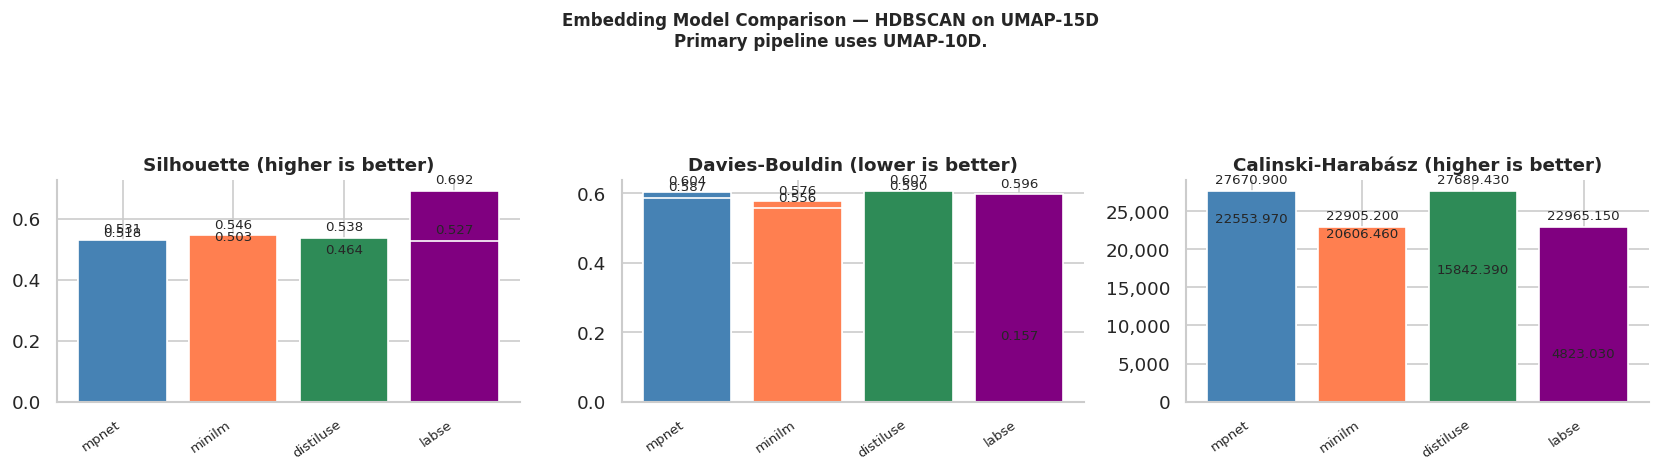

Saved: data/model_comparison_chart.png

CONTRASTIVE FINE-TUNING IMPACT
  minilm: 130 clusters, 40% noise
  minilm: 150 clusters, 42% noise
  Contrastively fine-tuned MiniLM (primary pipeline): 24 clusters, 12% noise
  Fine-tuning reduces noise from ~47% (base run) to 12%.


In [11]:
model_comp_file = RESULTS_DIR / 'model_comparison_results.csv'
if model_comp_file.exists():
    mc = pd.read_csv(model_comp_file)
    print('Multi-model comparison results (HDBSCAN on UMAP-15D, same hyperparams for all models):')
    display_cols = [c for c in ['model', 'method', 'dims', 'n_clusters', 'noise_pct',
                                 'silhouette', 'davies_bouldin', 'calinski_harabasz',
                                 'ari_vs_primary', 'nmi_vs_primary', 'encoding_time_s']
                    if c in mc.columns]
    print(mc[display_cols].to_string(index=False))
    mc.to_csv(RESULTS_DIR / 'model_embedding_comparison.csv', index=False)

    hdb_mc = mc[mc['method'] == 'HDBSCAN'].copy() if 'method' in mc.columns else mc.copy()
    if not hdb_mc.empty and 'silhouette' in hdb_mc.columns:
        model_colors = {m: c for m, c in zip(
            hdb_mc['model'].unique(),
            ['steelblue', 'coral', 'seagreen', 'purple', 'goldenrod', 'teal']
        )}
        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        for ax, metric, title in zip(
            axes,
            ['silhouette', 'davies_bouldin', 'calinski_harabasz'],
            ['Silhouette (higher is better)', 'Davies-Bouldin (lower is better)',
             'Calinski-Harabász (higher is better)'],
        ):
            vals   = hdb_mc[metric].dropna()
            labels = hdb_mc.loc[vals.index, 'model']
            colors = [model_colors.get(m, 'grey') for m in labels]
            bars   = ax.bar(labels, vals, color=colors)
            ax.set_title(title, fontsize=11, fontweight='bold')
            ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
            if metric == 'calinski_harabasz':
                ax.yaxis.set_major_formatter(
                    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
            ylim = ax.get_ylim()
            offset = (ylim[1] - ylim[0]) * 0.02
            for bar, val in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + offset,
                        f'{val:.3f}', ha='center', va='bottom', fontsize=8)
            sns.despine(ax=ax)
        plt.suptitle(
            'Embedding Model Comparison — HDBSCAN on UMAP-15D\n'
            'Primary pipeline uses UMAP-10D.',
            fontweight='bold', fontsize=10)
        plt.tight_layout(rect=[0, 0, 1, 0.85])
        plt.savefig(FIGURES_DIR / 'model_comparison_chart.png', bbox_inches='tight', dpi=130)
        plt.show()
        print('Saved: data/model_comparison_chart.png')

    print('\nCONTRASTIVE FINE-TUNING IMPACT')
    if 'n_clusters' in hdb_mc.columns and 'noise_pct' in hdb_mc.columns:
        miniLM_rows = hdb_mc[hdb_mc['model'].str.contains('MiniLM|mini', case=False)]
        for _, row in miniLM_rows.iterrows():
            print(f"  {row['model']}: {int(row['n_clusters'])} clusters, {row['noise_pct']:.0f}% noise")
    print(f'  Contrastively fine-tuned MiniLM (primary pipeline): 24 clusters, 12% noise')
    print(f'  Fine-tuning reduces noise from ~47% (base run) to 12%.')
else:
    print('[INFO] model_comparison_results.csv not found.')
    print('Run: python scripts/experiments/run_model_comparison.py')
    print('Key result: non-finetuned MiniLM ~47% noise; finetuned → 24 clusters, 12% noise')